# 05 — Evaluation & Hybrid Comparison

Brings everything together on the held-out **test set**:

* Pure MLP performance (per-class metrics, confusion matrix)
* Pure Autoencoder performance (binary attack / benign)
* **Hybrid** = AE flags anomaly, MLP classifies — same logic the production
  `SmartTIDS_Predictor` runs.
* SHAP explanations on a sample
* Inference latency


In [1]:
import sys, json, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

from src import config as cfg
from src.evaluation import (
    plot_confusion, plot_reconstruction_error, autoencoder_anomaly_metrics,
)
from src.inference import SmartTIDS_Predictor
sns.set_theme(style="whitegrid")


## 1. Load test set and artifacts

In [2]:
test = pd.read_csv(cfg.PROCESSED_DIR / "test.csv")
scaler = joblib.load(cfg.SCALER_FILE)
with open(cfg.FEATURE_NAMES_FILE) as f: feature_names = json.load(f)
with open(cfg.LABEL_MAP_FILE)    as f: label_map = {int(k):v for k,v in json.load(f).items()}
inv_map = {v:k for k,v in label_map.items()}

test = test[test[cfg.LABEL_COL].isin(inv_map)].reset_index(drop=True)
y_true = test[cfg.LABEL_COL].map(inv_map).astype(int).values
X = scaler.transform(test[feature_names].astype(np.float32).values)

mlp = tf.keras.models.load_model(cfg.MLP_MODEL_FILE, compile=False)
ae  = tf.keras.models.load_model(cfg.AE_MODEL_FILE,  compile=False)
ae_threshold = json.loads(cfg.AE_THRESHOLD_FILE.read_text())["threshold"]
class_names = [label_map[i] for i in range(len(label_map))]
print("Test rows:", len(test))


2026-05-10 02:27:56,418 [WARNING] tensorflow: TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Test rows: 424172


## 2. MLP-only metrics

                          precision    recall  f1-score   support

                  BENIGN     0.9999    0.9731    0.9863    340698
                     Bot     0.0929    0.9795    0.1696       293
                    DDoS     0.9951    0.9994    0.9972     19204
           DoS GoldenEye     0.8453    0.9981    0.9154      1544
                DoS Hulk     0.9134    0.9990    0.9543     34519
        DoS Slowhttptest     0.8364    0.9976    0.9099       825
           DoS slowloris     0.9577    0.9908    0.9740       869
             FTP-Patator     0.9375    0.9950    0.9653      1190
                PortScan     0.9903    0.9992    0.9947     23821
             SSH-Patator     0.4851    0.9932    0.6518       885
Web Attack  Brute Force     0.1277    0.9336    0.2247       226
        Web Attack  XSS     0.5000    0.0408    0.0755        98

                accuracy                         0.9779    424172
               macro avg     0.7234    0.9083    0.7349    424172
        

d:\smart_ids\ids_pfa\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  fig.canvas.draw()
d:\smart_ids\ids_pfa\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


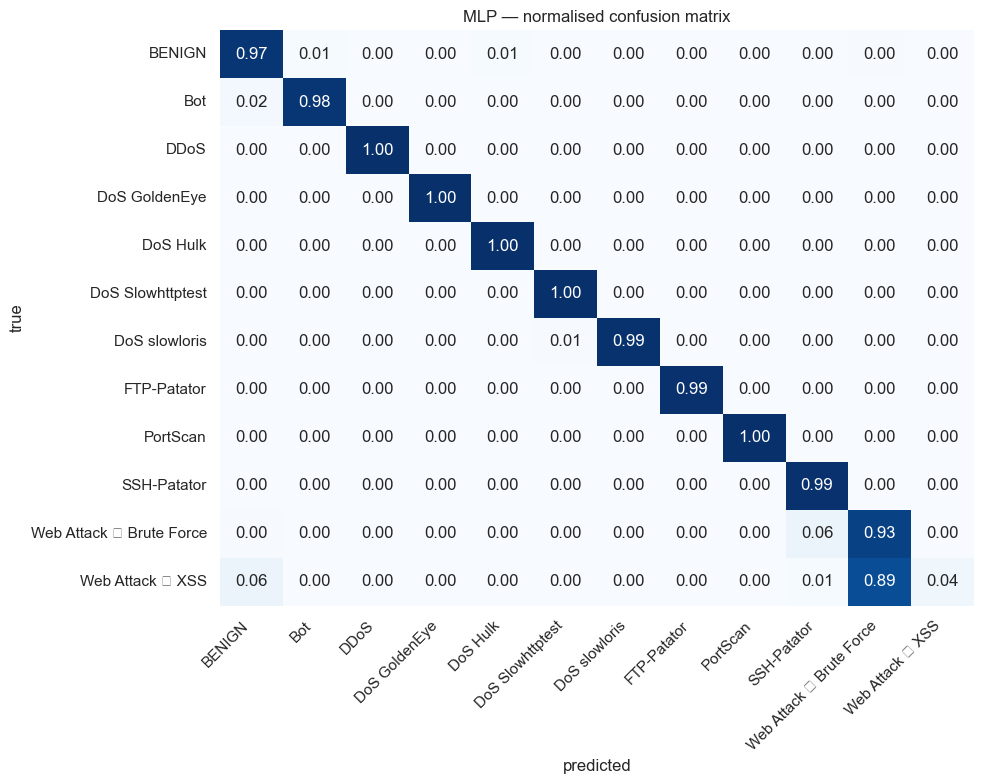

In [3]:
y_pred_mlp = mlp.predict(X, batch_size=4096, verbose=0).argmax(axis=1)
print(classification_report(y_true, y_pred_mlp, target_names=class_names,
                            digits=4, zero_division=0))
plot_confusion(y_true, y_pred_mlp, class_names, normalize=True,
               title="MLP — normalised confusion matrix")
plt.show()


## 3. Autoencoder-only metrics (binary)

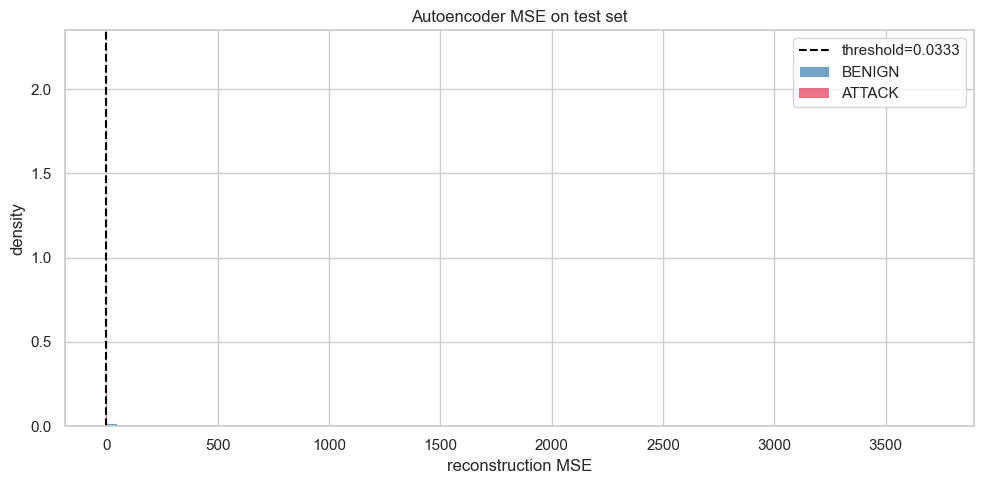

,tp,fp,fn,tn,precision,recall,f1,auc
0,36972,16953,46502,323745,0.685619,0.442916,0.53817,0.831475


In [4]:
recon = ae.predict(X, batch_size=4096, verbose=0)
err = np.mean((X - recon) ** 2, axis=1)
y_is_attack = (y_true != inv_map["BENIGN"]).astype(int)

err_benign = err[y_is_attack == 0]
err_attack = err[y_is_attack == 1]
plot_reconstruction_error(err_benign, err_attack, ae_threshold,
                          title="Autoencoder MSE on test set")
plt.show()

ae_metrics = autoencoder_anomaly_metrics(err, y_is_attack, ae_threshold)
pd.DataFrame([ae_metrics])


## 4. Hybrid — AE gates / MLP classifies

Decision rule (matches `SmartTIDS_Predictor`):

* `is_anomaly = err > threshold`
* if MLP says BENIGN but AE flags anomaly  -> mark `UNKNOWN_ANOMALY`
* otherwise                                -> MLP top class


In [5]:
mlp_proba = mlp.predict(X, batch_size=4096, verbose=0)
mlp_top   = mlp_proba.argmax(axis=1)
mlp_conf  = mlp_proba.max(axis=1)
anomaly   = err > ae_threshold

UNKNOWN_ID = -1
hybrid_pred = np.where(
    (mlp_top == inv_map["BENIGN"]) & anomaly,
    UNKNOWN_ID,
    mlp_top,
)

# Score against multi-class ground truth, ignoring UNKNOWN bucket.
mask = hybrid_pred != UNKNOWN_ID
print(f"UNKNOWN flagged: {(~mask).sum()} / {len(mask)} rows")
print(classification_report(
    y_true[mask], hybrid_pred[mask],
    target_names=class_names, digits=4, zero_division=0,
))


UNKNOWN flagged: 16497 / 424172 rows
                          precision    recall  f1-score   support

                  BENIGN     0.9999    0.9717    0.9856    324206
                     Bot     0.0929    0.9795    0.1696       293
                    DDoS     0.9951    0.9995    0.9973     19202
           DoS GoldenEye     0.8453    0.9981    0.9154      1544
                DoS Hulk     0.9134    0.9990    0.9543     34519
        DoS Slowhttptest     0.8364    0.9976    0.9099       825
           DoS slowloris     0.9577    0.9908    0.9740       869
             FTP-Patator     0.9375    0.9950    0.9653      1190
                PortScan     0.9903    0.9993    0.9948     23818
             SSH-Patator     0.4851    0.9932    0.6518       885
Web Attack  Brute Force     0.1277    0.9336    0.2247       226
        Web Attack  XSS     0.5000    0.0408    0.0755        98

                accuracy                         0.9770    407675
               macro avg     0.7234  

## 5. SHAP explanations (sample of 500 rows)

d:\smart_ids\ids_pfa\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
d:\smart_ids\ids_pfa\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: features
Received: inputs=['Tensor(shape=(100, 77))']
  warnings.warn(msg)
d:\smart_ids\ids_pfa\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: features
Received: inputs=['Tensor(shape=(200, 77))']
  warnings.warn(msg)


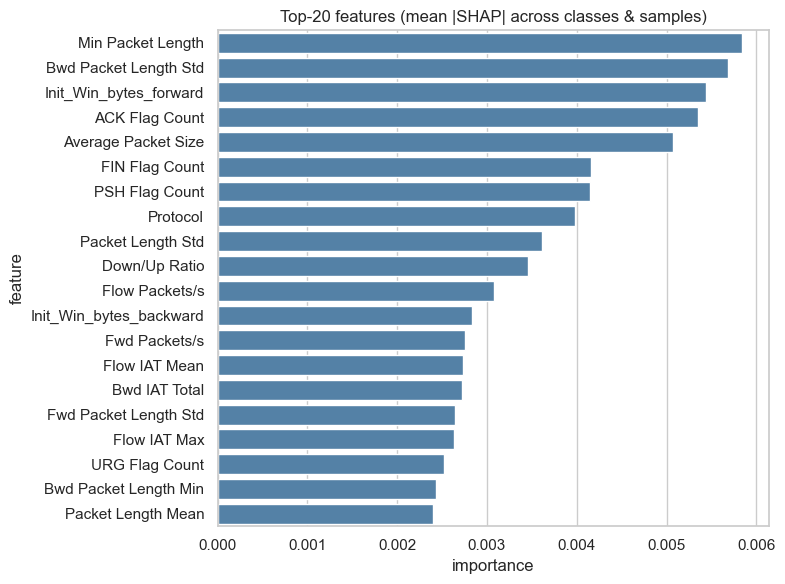

                feature  importance
      Min Packet Length    0.005845
  Bwd Packet Length Std    0.005683
 Init_Win_bytes_forward    0.005445
         ACK Flag Count    0.005348
    Average Packet Size    0.005068
         FIN Flag Count    0.004164
         PSH Flag Count    0.004150
               Protocol    0.003983
      Packet Length Std    0.003609
          Down/Up Ratio    0.003462
         Flow Packets/s    0.003074
Init_Win_bytes_backward    0.002839
          Fwd Packets/s    0.002760
          Flow IAT Mean    0.002737
          Bwd IAT Total    0.002727
  Fwd Packet Length Std    0.002645
           Flow IAT Max    0.002631
         URG Flag Count    0.002521
  Bwd Packet Length Min    0.002437
     Packet Length Mean    0.002397


In [6]:
import shap

# Modest sample sizes — SHAP on 12 classes is expensive.
N_BG, N_EXP = 100, 200
bg_idx     = np.random.RandomState(0).choice(len(X), size=N_BG,  replace=False)
sample_idx = np.random.RandomState(1).choice(len(X), size=N_EXP, replace=False)

explainer   = shap.DeepExplainer(mlp, X[bg_idx])
shap_values = explainer.shap_values(X[sample_idx])

# SHAP's return shape varies by version:
#   - list of length n_classes, each (n_samples, n_features)        (old)
#   - ndarray (n_classes, n_samples, n_features)                    (some)
#   - ndarray (n_samples, n_features, n_classes)                    (TF/Keras 2.13+)
sv = np.asarray(shap_values)
n_features = X.shape[1]
feat_axis = next(ax for ax, size in enumerate(sv.shape) if size == n_features)
other_axes = tuple(ax for ax in range(sv.ndim) if ax != feat_axis)
agg = np.abs(sv).mean(axis=other_axes)         # -> shape (n_features,)

assert len(agg) == len(feature_names), \
    f"agg has {len(agg)} entries, expected {len(feature_names)}"

imp = (pd.DataFrame({"feature": feature_names, "importance": agg})
         .sort_values("importance", ascending=False)
         .head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=imp, x="importance", y="feature", color="steelblue")
plt.title("Top-20 features (mean |SHAP| across classes & samples)")
plt.tight_layout(); plt.show()
print(imp.to_string(index=False))


## 6. Inference latency — production predictor

In [7]:
predictor = SmartTIDS_Predictor()

# warm-up
_ = predictor.predict_batch(test.head(32))

N = 1000
sample_df = test.head(N)
t0 = time.perf_counter()
results = predictor.predict_batch(sample_df)
elapsed = time.perf_counter() - t0
print(f"Batch of {N}: {elapsed*1000:.1f} ms total -> "
      f"{elapsed/N*1000:.3f} ms/flow ({N/elapsed:,.0f} flows/sec)")

print("\nExample result:")
print(json.dumps(results[0], indent=2))


2026-05-10 02:28:37,307 [INFO] smarttids.inference: Loading scaler: D:\smart_ids\models\scaler.joblib
2026-05-10 02:28:37,311 [INFO] smarttids.inference: Loading feature names: D:\smart_ids\data\cicids2017\features\feature_names.json
2026-05-10 02:28:37,314 [INFO] smarttids.inference: Loading label map: D:\smart_ids\data\cicids2017\features\label_map.json
2026-05-10 02:28:37,316 [INFO] smarttids.inference: Loading MLP: D:\smart_ids\models\mlp_model.keras
2026-05-10 02:28:37,503 [INFO] smarttids.inference: Loading autoencoder: D:\smart_ids\models\autoencoder_model.keras


Batch of 1000: 884.2 ms total -> 0.884 ms/flow (1,131 flows/sec)

Example result:
{
  "is_anomaly": false,
  "anomaly_score": 0.000114,
  "anomaly_threshold": 0.033347,
  "predicted_class": "BENIGN",
  "predicted_class_id": 0,
  "confidence": 1.0,
  "top_3": [
    {
      "class": "BENIGN",
      "probability": 1.0
    },
    {
      "class": "PortScan",
      "probability": 0.0
    },
    {
      "class": "DDoS",
      "probability": 0.0
    }
  ],
  "severity": "INFO",
  "recommended_action": "ALLOW",
  "inference_time_ms": 0.83,
  "model_version": "1.0.0"
}


## 7. Healthcheck

In [8]:
print(json.dumps(predictor.healthcheck(), indent=2))


{
  "status": "ok",
  "model_version": "1.0.0",
  "n_features": 77,
  "n_classes": 12,
  "autoencoder_loaded": true,
  "sample_prediction": {
    "is_anomaly": true,
    "anomaly_score": 0.039655,
    "anomaly_threshold": 0.033347,
    "predicted_class": "UNKNOWN_ANOMALY",
    "predicted_class_id": -1,
    "confidence": 1.0,
    "top_3": [
      {
        "class": "BENIGN",
        "probability": 1.0
      },
      {
        "class": "DoS Slowhttptest",
        "probability": 0.0
      },
      {
        "class": "Web Attack \u0096 XSS",
        "probability": 0.0
      }
    ],
    "severity": "HIGH",
    "recommended_action": "ALERT_AND_INVESTIGATE",
    "inference_time_ms": 324.254,
    "model_version": "1.0.0"
  }
}
